In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv("files/student_performance_prediction.csv")
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No


In [4]:
missing_values = df.isnull().sum()
print(missing_values)

Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                                1994
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Passed                                         2000
dtype: int64


In [5]:
missing_values = df.isnull().sum()
print(missing_values)

      Student ID  Study Hours per Week  Attendance Rate  Previous Grades  \
0         S00001                  12.5        75.276323        75.000000   
1         S00002                   9.3        95.300000        60.600000   
2         S00003                  13.2        75.276323        64.000000   
3         S00004                  17.6        76.800000        62.400000   
4         S00005                   8.8        89.300000        72.700000   
...          ...                   ...              ...              ...   
39995     S39996                  15.6        93.800000        51.400000   
39996     S39997                  11.3        66.400000        64.200000   
39997     S39998                  13.1        65.600000        38.100000   
39998     S39999                  14.1        74.900000        65.440107   
39999     S40000                  11.8        55.100000        68.500000   

      Participation in Extracurricular Activities Parent Education Level  \
0          

<function matplotlib.pyplot.show(close=None, block=None)>

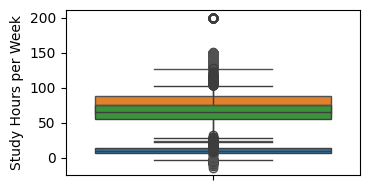

In [14]:
numerical_cols = ["Study Hours per Week", "Attendance Rate", "Previous Grades"]
plt.figure(figsize=(10,2))
for i,column in enumerate(numerical_cols,3):
    plt.subplot(1,3,1)
    sns.boxplot(y=df[column])
plt.tight_layout()
plt.show

In [7]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_outliers = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_outliers
numerical_cols = ["Study Hours per Week", "Attendance Rate", "Previous Grades"]
df_outliers = df.copy()
for col in numerical_cols:
    df_outliers = remove_outliers(df_outliers, col)
print("Original DataFrame rows:", df.shape[0])
print("DataFrame after removing outliers:", df_outliers.shape[0])

Original DataFrame rows: 40000
DataFrame after removing outliers: 38577


In [8]:
label_enc = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_enc.fit_transform(df[col])
print(df.head())

   Student ID  Study Hours per Week  Attendance Rate  Previous Grades  \
0           0                  12.5        75.276323             75.0   
1           1                   9.3        95.300000             60.6   
2           2                  13.2        75.276323             64.0   
3           3                  17.6        76.800000             62.4   
4           4                   8.8        89.300000             72.7   

   Participation in Extracurricular Activities  Parent Education Level  Passed  
0                                            1                       4       1  
1                                            0                       3       0  
2                                            0                       0       0  
3                                            1                       1       0  
4                                            0                       4       0  


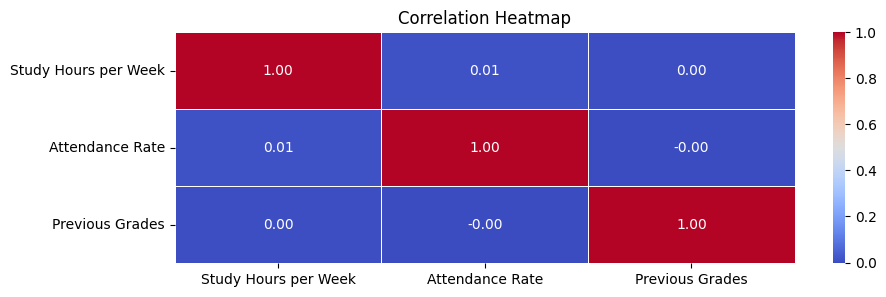

In [17]:
numerical_df = df_outliers.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(10, 3))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

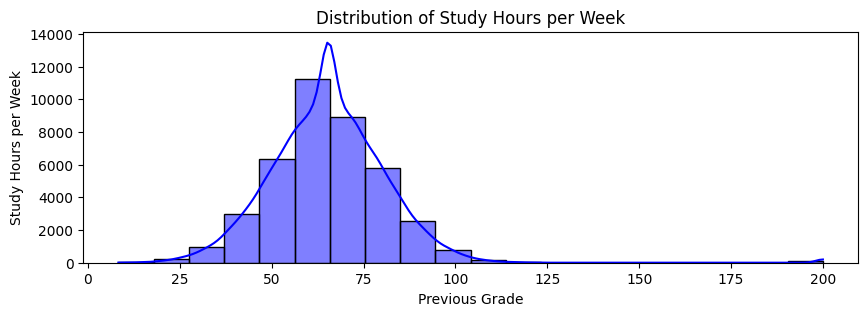

In [18]:
plt.figure(figsize=(10,3))
sns.histplot(df["Previous Grades"], bins=20, kde=True, color="blue")
plt.xlabel("Previous Grade")
plt.ylabel("Study Hours per Week")
plt.title("Distribution of Study Hours per Week")
plt.show()

In [11]:
Target_column = "Previous Grades"
x = df.drop(columns=[Target_column])
y = df[Target_column]
print("Independent features (X):", x.shape)
print("Target column (y):", y.shape)
print("First 5 rows of X (features):")
print(x.head())
print("First 5 rows of y (Target column):")
print(y.head())

Independent features (X): (40000, 6)
Target column (y): (40000,)
First 5 rows of X (features):
   Student ID  Study Hours per Week  Attendance Rate  \
0           0                  12.5        75.276323   
1           1                   9.3        95.300000   
2           2                  13.2        75.276323   
3           3                  17.6        76.800000   
4           4                   8.8        89.300000   

   Participation in Extracurricular Activities  Parent Education Level  Passed  
0                                            1                       4       1  
1                                            0                       3       0  
2                                            0                       0       0  
3                                            1                       1       0  
4                                            0                       4       0  
First 5 rows of y (Target column):
0    75.0
1    60.6
2    64.0
3    62.4
4    72

In [46]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
x_normalized = pd.DataFrame(x_scaled, columns=x.columns)
print(x_normalized.head())

   Student ID  Study Hours per Week  Attendance Rate  \
0    0.000000              0.554810         0.544537   
1    0.000025              0.483221         0.666261   
2    0.000050              0.570470         0.544537   
3    0.000075              0.668904         0.553799   
4    0.000100              0.472036         0.629787   

   Participation in Extracurricular Activities  Parent Education Level  Passed  
0                                          0.5                     0.8     0.5  
1                                          0.0                     0.6     0.0  
2                                          0.0                     0.0     0.0  
3                                          0.5                     0.2     0.0  
4                                          0.0                     0.8     0.0  


MAE: 0.00, MSE: 0.00, RMSE: 0.00, R²: 1.00


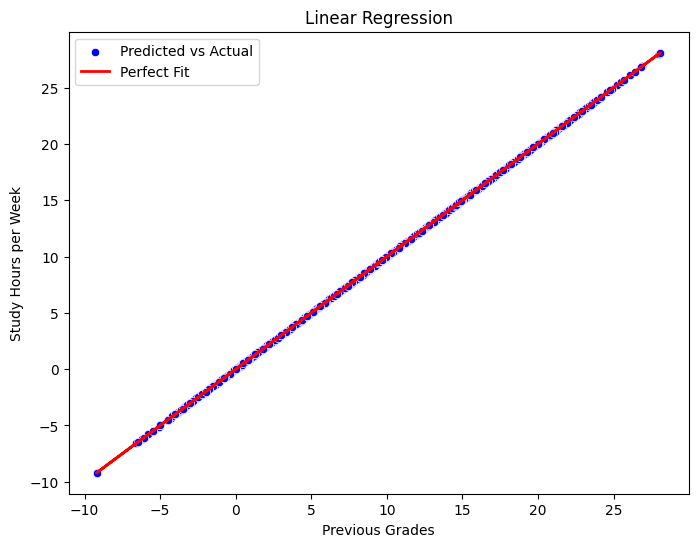

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
x = df.drop(columns=["Previous Grades"])
y = df["Study Hours per Week"]
label_encoder = {}
for col in x.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoder[col] = le
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color="blue", label="Predicted vs Actual")
plt.plot(y_test, y_test, color="red", linewidth=2, label="Perfect Fit")
plt.xlabel("Previous Grades")
plt.ylabel("Study Hours per Week")
plt.title("Linear Regression")
plt.legend()
plt.show()
